In [9]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model

<h1>Loading Data</h1>

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


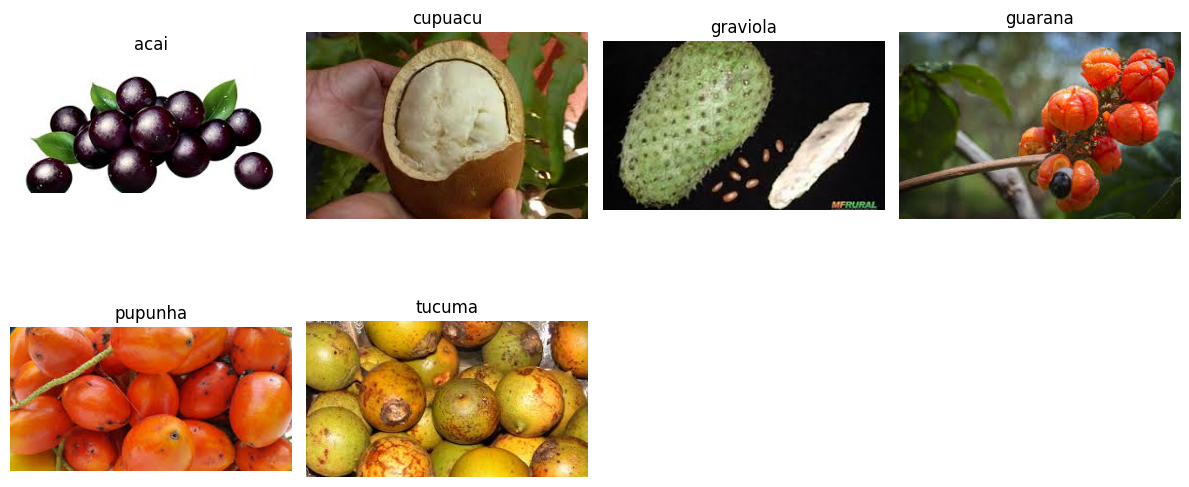

In [3]:
train_dir = "FruitinAmazon/train"

# Get class names
classes = os.listdir(train_dir)
print("Classes:", classes)

# Select one random image from each class
images = []
titles = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    images.append(Image.open(img_path))
    titles.append(cls)

# Plot in grid (2 rows)
plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, (len(images)//2)+1, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalize layer
rescale = tf.keras.layers.Rescaling(1./255)

# Train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [5]:
num_classes = len(classes)

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])

C:\Users\LEGION\OneDrive\Desktop\Sem6\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.1904 - loss: 2.5466

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 844ms/step - accuracy: 0.1806 - loss: 2.8516 - val_accuracy: 0.8333 - val_loss: 1.4390
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 328ms/step - accuracy: 0.1667 - loss: 1.7810 - val_accuracy: 0.6667 - val_loss: 1.6257
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step - accuracy: 0.3889 - loss: 1.7235 - val_accuracy: 0.3889 - val_loss: 1.7285
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 350ms/step - accuracy: 0.4167 - loss: 1.6433 - val_accuracy: 0.0000e+00 - val_loss: 1.7183
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.2083 - loss: 1.5388 - val_accuracy: 0.1111 - val_loss: 1.6369
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 323ms/step - accuracy: 0.3333 - loss: 1.4168 - val_accuracy: 0.3889 - val_loss: 1.5926
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.5642 - loss: 1.2456

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 467ms/step - accuracy: 0.5833 - loss: 1.2681 - val_accuracy: 0.4444 - val_loss: 1.4369
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7598 - loss: 1.1169

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 352ms/step - accuracy: 0.7639 - loss: 1.0980 - val_accuracy: 0.6667 - val_loss: 1.1175
Epoch 9/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7891 - loss: 0.8545 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.6944 - loss: 0.9336 - val_accuracy: 0.8889 - val_loss: 0.7787
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8194 - loss: 0.7273 - val_accuracy: 0.6667 - val_loss: 0.9534
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8472 - loss: 0.5920 - val_accuracy: 0.5556 - val_loss: 1.3189
Epoch 12/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8984 - loss: 0.4693

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8889 - loss: 0.4640 - val_accuracy: 0.8333 - val_loss: 0.5549
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9306 - loss: 0.3676 - val_accuracy: 0.7778 - val_loss: 0.6071
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9861 - loss: 0.2151 - val_accuracy: 0.6667 - val_loss: 0.9388
Epoch 15/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9688 - loss: 0.2214

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9722 - loss: 0.2066 - val_accuracy: 0.8333 - val_loss: 0.4391
Epoch 16/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9688 - loss: 0.1734

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9444 - loss: 0.1773 - val_accuracy: 0.9444 - val_loss: 0.2561
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9861 - loss: 0.1239 - val_accuracy: 0.7778 - val_loss: 0.4661
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9861 - loss: 0.0859 - val_accuracy: 0.8333 - val_loss: 0.5646
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 1.0000 - loss: 0.0575 - val_accuracy: 0.8333 - val_loss: 0.4434
Epoch 20/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0463 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 1.0000 - loss: 0.0410 - val_accuracy: 0.8889 - val_loss: 0.1998
Epoch 21/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 0.0249

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 1.0000 - loss: 0.0323 - val_accuracy: 0.9444 - val_loss: 0.1795
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - loss: 0.0207 - val_accuracy: 0.8333 - val_loss: 0.4973
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9861 - loss: 0.0390 - val_accuracy: 0.8333 - val_loss: 0.5113
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 1.0000 - loss: 0.0131 - val_accuracy: 0.8333 - val_loss: 0.5180
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 1.0000 - loss: 0.0133 - val_accuracy: 0.8333 - val_loss: 0.3526
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 0.8333 - val_loss: 0.2533
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 0.9444 - val_loss: 0.2525
Epoch 28/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 0.9444 - val_loss: 0.2

In [8]:
test_dir = "FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128,128),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7667 - loss: 0.7517
Test Accuracy: 0.7666666507720947


In [10]:
# Save
model.save("final_model.h5")

# Load
loaded_model = load_model("final_model.h5")

# Re-evaluate
loaded_model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.7667 - loss: 0.7517


[0.7517096400260925, 0.7666666507720947]

In [11]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
              precision    recall  f1-score   support

        acai       0.56      1.00      0.71         5
     cupuacu       0.83      1.00      0.91         5
    graviola       1.00      0.80      0.89         5
     guarana       0.75      0.60      0.67         5
     pupunha       0.80      0.80      0.80         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.77        30
   macro avg       0.82      0.77      0.76        30
weighted avg       0.82      0.77      0.76        30



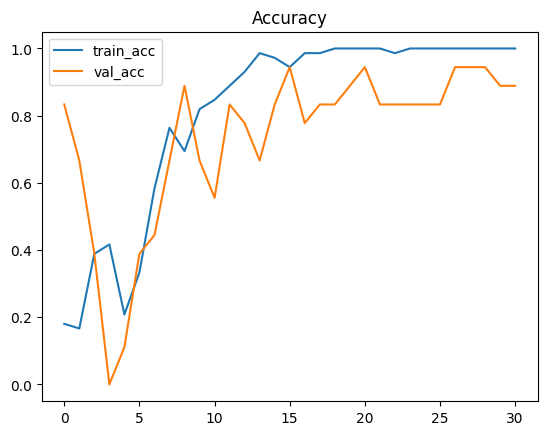

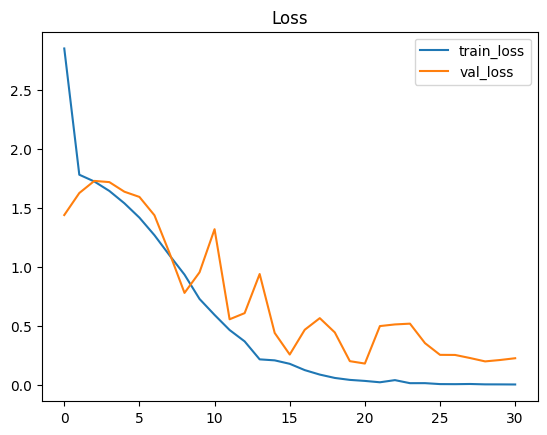

In [12]:
# Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()